# Reproducible Boolean model analyses and simulations with the CoLoMoTo software suite: a tutorial

Vincent Noël<sup>1,2,3</sup>, Aurélien Naldi<sup>4</sup>, Laurence Calzone<sup>1,2,3</sup>,  Loïc Paulevé<sup>5</sup>, Denis Thieffry<sup>1,2,3,4</sup>   

<sup>1</sup> Institut Curie, INSERM U900, Mines Paris, PSL Université, Paris, France. <br>
<sup>2</sup> INSERM, U1331, F-75005, Paris, France.<br>
<sup>3</sup> Mines ParisTech, Université PSL, F-75005, Paris, France.<br>
<sup>4</sup> Département de biologie, PSL Université, Paris, France.<br>
<sup>5</sup> LaBRI, CNRS UMR 5800, INP, Université de Bordea

August 22nd, 2025 - Supplementary materiel to the article published in *Interface Focus*, 2015 - https://doi.org/10.1098/rsfs.2025.0002

#### Abstract
This notebook provides stepwise instructions to install over 20 tools,
written in multiple languages. Their integration in the *CoLoMoTo*
software suite makes them accessible with a single popular language
(*Python*), thereby enabling reproducible and sophisticated dynamical
analyses of logical models of complex cellular networks. The notebook
specifically focuses on the analysis of a previously published model of
the regulatory network controlling mammalian cell proliferation. It
includes chunks of *Python* code to reproduce several of the results and
figures published in the original article, and further extends these
results with the help of selected tools included in the *CoLoMoTo*
suite. The notebook covers the visualisation of the network with the
tool *GINsim*, an attractor analysis with *bioLQM*, the computation of
synchronous attractors with *BNS*, the extraction of modules from the
full model, stochastic simulations of the wild-type model and of
selected perturbations with *MaBoSS* and finally the delineation of
compressed probabilistic state transition graphs. The integration of all
these analyses in an executable *Jupyter* notebook greatly eases their
reproducibility, as well as the inclusion of further extensions. This notebook further constitutes a template, which can be enriched with other *ColoMoTo* tools, to develop comprehensive dynamical analyses of various biological network models.


## 1. Introduction

Since the seminal studies from Sugita \[[1](#B1)\], Kauffman \[[2](#B2)\] and Thomas \[[3](#B3)\], Boolean models have been increasingly applied to biological signalling and regulatory networks \[[4](#B4)–[7](#B7)\]. With the rise of high-throughput functional genomic methods and the development of molecular pathway knowledge databases, modellers are now coping with networks encompassing hundreds of regulatory components controlling cell fate decisions for normal and pathological conditions (e.g. \[[8](#B8)\]).

In parallel, dozens of computational tools have been developed to infer, edit and analyse the dynamical properties of Boolean networks, using different programming languages and model formats (see, e.g., \[[9](#B9)\] and references therein). However, like experimental biologists, modellers are facing serious reproducibility challenges, which have been stressed in recent years (see \[[10](#B10)\], focusing on modelling studies using ordinary differential equations).

About a decade ago, several international teams working on the development of Boolean modelling tools gathered efforts to address these challenges. A first effort focused on the definition of a common standard format to foster the exchange and reuse of qualitative models between different software tools, which took the form of a dedicated extension of a new, modular release of the popular *SBML* format, known as *sbml-qual* \[[11](#B11)\].

A second, recurrent effort is devoted to the integration of a growing set of tools in a *Docker* container to ease their installation and articulation in flexible analysis workflows. The first release of the resulting *Common Logical Modelling Toolbox* (or *CoLoMoTo*) encompassed six complementary software tools \[[12](#B12)\]. Since then, the number of tools integrated into the *CoLoMoTo* suite has been constantly increasing, reaching a total of 24 in 2025. The tools currently integrated in the suite are listed in **figure 1**, with key characteristics.

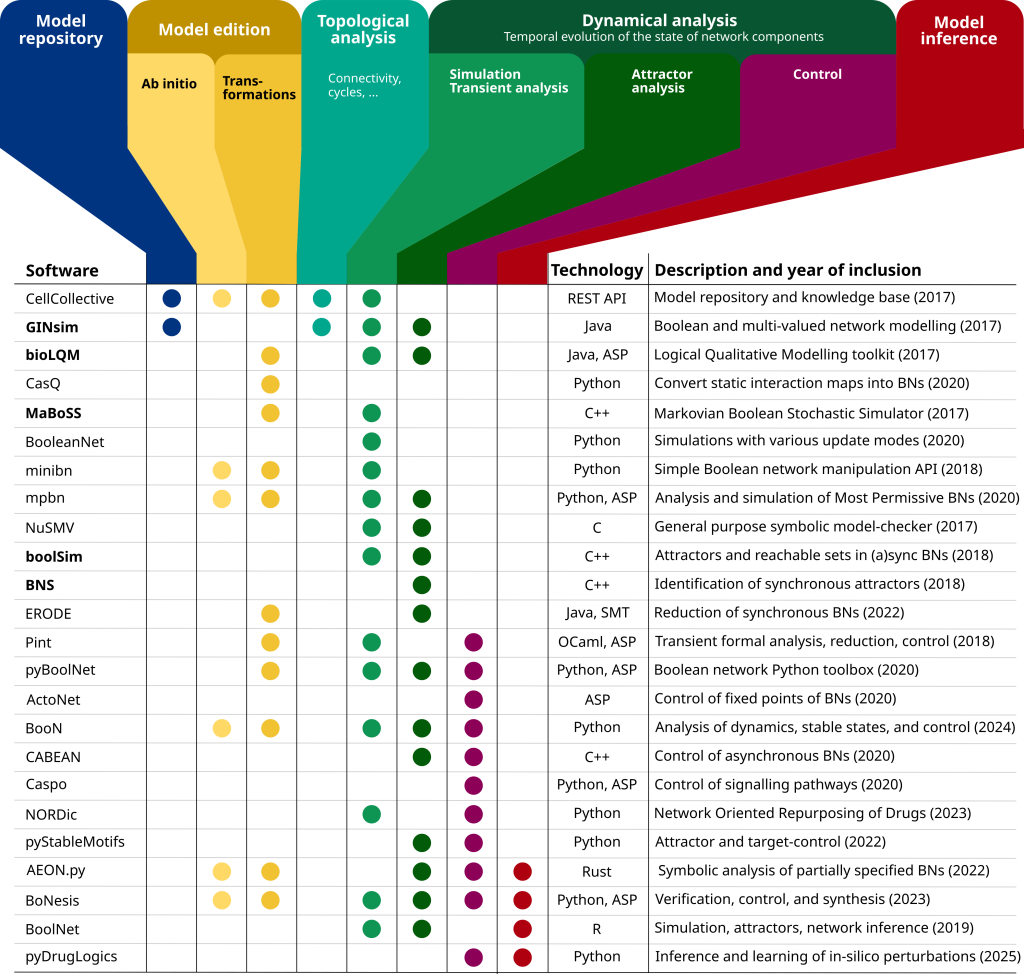

**Figure 1.** Tools integrated in the CoLoMoTo suite. Names in bold refer to the *CoLoMoTo* tools used in this notebook. 

This notebook aims to help modellers take advantage of the multiple tools integrated into the *CoLoMoTo* software suite and perform sophisticated Boolean model analyses of complex signalling/regulatory networks. This notebook relies on a comprehensive model of key signalling pathways and a core regulatory network controlling mammalian cell proliferation, published by Sizek *et al*. \[[13](#B13)\]. The proposed tasks performed with selected tools aim at comparing the model outcomes with expected experimental behaviours (e.g. existence of cell states in response to receptor activation, cell differentiation, etc.), predicting the results of potential perturbations (such as mutations in patients) or anticipating the effect of treatments.

As we shall see, the notebook includes chunks of *Python* code to reproduce several of the results and figures published in the original article, and further extends these results with the help of several tools included in the *CoLoMoTo* software suite, in particular taking advantage of the *MaBoSS* package to perform stochastic simulations for the wild-type (WT) and various mutant backgrounds. This notebook specifically aims to demonstrate the added value of combining different tools to perform reproducible dynamic analyses, and shows the effectiveness of using *Python* to orchestrate these different analyses.

## 2. Material and methods

## 2.1. Installation

The notebook can be run on a recent personal computer with at least 16
Go of RAM and about 10 Go of available disk space.

The *CoLoMoTo* suite can be installed either as a *Docker* container or
as individual *conda* packages.


### 2.1.1.  Installation of the CoLoMoTo Docker container

*Docker* allows packaging a complete pre-installed software environment,
so that applications can run consistently across different machines and
operating systems. As such, it is well adapted to reproduce complex
computational workflows, relying on numerous software.

*Docker* and *Python* need to be pre-installed. Go to your folder and
then type in a terminal:

```
pip install -U colomoto-docker
colomoto-docker -V 2025-03-01 --bind .
```

### 2.1.2. Installation of CoLoMoTo conda packages
As an alternative to using *Docker*, one can rely on *conda* to create a software environment able to reproduce the notebook on *Linux* and *macOS* computers by typing the following commands in a terminal:

```
conda create -n sizek19 -c colomoto -c potassco -c conda-forge ginsim-python bns-python boolsim-python pymaboss notebook seaborn numpy pandas matplotlib
conda activate sizek19
```

To launch this notebook, type the command:

```
jupyter notebook
```

Because *BNS* and *boolSim* executables are not available for *Windows®* operating systems, the complete notebook can be executed only within *Docker* on these systems.

More generally, as the versions of package dependencies cannot be fully controlled with *conda*, reproducibility is better ensured by using the *Docker image*.  

## 2.2. Model

The model published by Sizek *et al.* \[[13](#B13)\] has been imported and edited with the *GINsim* software \[[14](#B14)\]. It is publicly available in the GINsim *zginml* model format (including the layout, to be open with *GINsim*, version ≥ 3.0), as well as in the *sbml-qual* format, in the *GINsim* model repository (<http://ginsim.org/>). Hence, the model can be directly loaded from the notebook using the link to the corresponding *GINsim* model repository entry. Alternatively, the model can be downloaded locally and the loading command modified accordingly, thereby enabling offline work.

The model was initially conceived as the combination of five main signalling/regulatory modules contributing to the decision between cell proliferation versus death. A first module accounts for the orchestration of the cell cycle, resulting in the successive activation of the main markers of the cell division process, the cyclins. A second module accounts for the control of apoptosis, represented by the activation of Casp3 and the influence of the TRAIL death signal. A third module represents the regulation of growth via the MAPK and PI3k/AKT pathways and their activation by environmental factors. A fourth module represents the G1 restriction point. A fifth module represents the regulation of the origin of replication. Connecting all these modules (displayed with different colours in figure 2), the model can account for many different cellular situations, including genetic alterations common in cancer, and can successfully reproduce observed phenotypes.


## 3. Model analysis


The following sections of the tutorial cover the following steps:

- Loading of the packages required for the notebook.

- Loading of the model and visualisation of the network with the
  software *GINsim.*

- Attractor analysis with the software *bioLQM.*

- Computation of synchronous attractors with *BNS.*

- Analysis of the attractors of the model modules using *bioLQM*, *BNS*
  and *boolSim*.

- Stochastic dynamical simulations of the wild type and mutant models
  with *MaBoSS.*

- The construction of compressed probabilistic transition graphs with
  *MaBoSS.*

This chaining of steps constitutes a coherent analysis workflow,
starting with the identification of attractors (stable states or
cycles), considering different updating schemes, before performing more
precise and complex stochastic simulations, for the wildtype case, as
well as for selected mutant backgrounds. Each step is performed using
one selected software tool, but other *CoLoMoTo* tools could be used to
perform similar analyses (cf. **Figure 1**).

### 3.1. Loading required packages


Before running the analyses, the packages to be used need to be loaded.
For this notebook, only the necessary *CoLoMoTo* packages are selected.
The other packages listed in **Figure 1** can be loaded according to the
instructions provided at
[https://colomoto.github.io/colomoto-docker/](https://colomoto.github.io/colomoto-docker/).
Note that these packages can also be loaded later on, just before their
use.

The execution of this cell outputs a few lines specifying what docker image and how many computer resources were used:

In [1]:
%%time
# Loading of CoLoMoTo tools and Python modules used in this tutorial.
import numpy as np
import pandas as pd
import seaborn as sns
import ginsim 
import biolqm 
import maboss
import bns
import boolsim
from colomoto_jupyter import tabulate # For fixpoint table display.
import matplotlib.pyplot as plt # For modifying plots.
import os

This notebook has been executed using the docker image `colomoto/colomoto-docker:2025-03-01`

CPU times: user 1.22 s, sys: 91.5 ms, total: 1.31 s
Wall time: 1.47 s


### 3.2 Loading and Visualisation of the model with GINsim

Prior to this notebook, the model was first imported using GINsim, in
order to redesign its layout and to associate extensive annotations with
each regulatory node. The resulting model has the same logical rules as
the original one and can be found in the *GINsim* repository at the
address: http://ginsim.org/node/258

To load the model and visualise its *regulatory graph*, we run the
following code cell:

In [2]:
# Loading and visualisation of the model.
model_ginsim = ginsim.load("https://ginsim.github.io/models/2019-mammal-cell-cycle-control/CellCycleControl_Sizek_PCB_2019.zginml")
ginsim.show(model_ginsim)

/notebook/CellCycleControl_Sizek_PCB_2019.zginml

**Figure 2.** Boolean model published by Sizek *et al*. \[[13](#B13)\]. The corresponding regulatory graph encompasses 87 nodes, representing different molecular species and cellular processes involved in the regulation of cell proliferation and apoptosis in a generic human cell. Green: growth signalling module; red: apoptosis module; yellow: origin of replication licensing module; blue: restriction point module; pink: cell phase control module; orange: nodes connecting different modules/processes; white: environmental factors. Green arrows and red blunt arcs denote activatory and inhibitory interactions, respectively.


The regulatory graph shown in **figure 2** encompasses 87 nodes representing different molecular species and cellular processes involved in the regulation of cell proliferation and apoptosis in a generic human cell. The authors conceived this complex model as an association of five main functional modules:

* The growth signalling module (green nodes) incorporates growth signalling pathways driving cell cycle commitment, responsible for modelling the dynamics of PI3K, AKT1, MAPK and mTORC.
* The restriction switch module (blue nodes) is responsible for commitment to DNA synthesis.
* The origin licensing switch module (yellow nodes) controls licensing and firing of replication origins.
* The phase switch module (pink nodes) controls cell cycle progression (G1 → S → G2 → M), taking into account the role of Polo-like kinase 1 (Plk1) during mitosis.
* The apoptosis switch module (red nodes) implements the decision between cell survival versus apoptosis.

In the regulatory graph, green arrows denote activatory interactions, while red blunt arcs represent inhibitions. As many model nodes are regulated by multiple nodes, their responses to regulatory input node levels are encoded in Boolean rules, which combine literals (i.e. node ids) with the classical Boolean operators NOT (written ‘!’ in *GINsim*), OR (‘\|’) and AND (‘&’). The rules defined in the initial publication were encoded in the *zginml* file available in the *GINsim* model repository.


### 3.3. Attractor analysis with *bioLQM*

*Attractors* represent the long-term (*asymptotic*) behaviours of the model. In the case of Boolean models, attractors can correspond to stable states (with each of the components frozen at level 0 or 1) or to periodic/cyclic behaviour (with a subset of components switching between values 0 or 1). Attractors are often associated with cellular phenotypes, cell fates (e.g. cell proliferation or cell death), or cellular types in the case of cell differentiation models. Their analysis allows the modeller to verify that the model reproduces the dynamical properties expected for the biological system under study, for normal or perturbed conditions.

To obtain a first overview of the asymptotic properties of the model, we can use the software tool *bioLQM* \[[15](#B15)\], which includes an efficient algorithm to identify all stable states \[[16](#B16)\]. The model is first converted into the *bioLQM* format, which can be achieved with the following code cell:

In [3]:
# Conversion of the model for biolqm.
model_biolqm = ginsim.to_biolqm(model_ginsim)

Using *bioLQM*, the *stable states* of the model can be computed by the
following code cell.

In [4]:
%%time
# Compute fixpoints.
fps = biolqm.fixpoints(model_biolqm)
print(len(fps), "fixpoints") # Shows the number of fixpoints.
tabulate(fps) # Table displaying all the fixpoints.

8 fixpoints
CPU times: user 120 ms, sys: 11.3 ms, total: 131 ms
Wall time: 234 ms


,GF,RTK,Grb2,Ras,RAF,mTORC2,PI3K,PIP3,PDK1,AKT_B,p110_H,PI3K_H,AKT_H,FoxO3,PLCgamma,NeddL4,FoxO1,p21_mRNA,TSC2,PRAS40,Rheb,mTORC1,S6K,eIF4E,GSK3,p21,pRB,p27Kip1,Myc,CyclinD1,E2F1,CyclinE,ORC,Cdc6,Cdt1,Pre_RC,geminin,CyclinA_mRNA,Emi1,FoxM1,Cdc25A,CyclinA,Wee1,UbcH10,CyclinB,Cdc25B,Plk1,Cdc25C,Cdk1,pAPC,Cdc20,Cdh1,Replication,f4N_DNA,U_Kinetochores,Mad2,A_Kinetochores,Plk1_H,Ect2,Casp8,Casp2,MCL_1,BCLXL,BCL2,BAD,BIK,BIM,BID,BAK,BAX,Cyto_C,SMAC,IAPs,Casp9,Casp3,CAD,ATR,CHK1,Ca2,DAG,DR4_5,ERK,GF_High,IP3,MEK,SOS,Trail
0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,1,0,0,0,0,0,1
2,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,1,0,0,0,0,0,1
5,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,1,0,1,0,0,0,1
6,1,1,0,0,0,1,1,1,1,1,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,1,1,0,0,0,1,1,1,1,1,1,0,0,1,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


The execution of this code cell takes less than a second and outputs a table listing the eight stable states (also called *fixed points*) of the model (shown in the notebook), matching those reported by Sizek *et al*. in the supplementary table S2 of their article.

To better visualise any of these stable states, the corresponding values can be projected on the model regulatory graph with a simple code line, using *GINsim*:

In [5]:
# Visualising the first fixed point from the table above.
ginsim.show(model_ginsim,fps[0])

**Figure 3.** Graphical representation of a stable state of the Boolean model published by Sizek *et al*. \[[13](#B13)\] corresponding to a cell death phenotype. Active nodes and their outgoing edges are displayed in blue.

Such a visualisation highlights the pathways/modules that are active in one particular stable state.

### 3.4. Computation of synchronous attractors with *BNS*

In their publication, Sizek *et al*. report the existence of a cyclic behaviour when a synchronous simulation method is used. Synchronous simulations simultaneously update all the components at a given state, according to the logical rules, leading to a unique successor state. This is a strong assumption, as in reality, timing plays an important role in biology and concurrent events barely occur simultaneously.

In contrast, asynchronous simulations typically update only one component at each time step, either selecting randomly one component to update, or yet considering separately all single update calls, potentially giving rise to more complex, non-deterministic dynamics.

Of note, for a given Boolean model, the stable states are not affected by the choice of updating, as stable states are devoid of update calls.

Cyclic attractors correspond to a circular sequence of events, such as the activation of cyclins, markers of the cell cycle. Cyclic attractors may depend on the choice of updating, and their identification is more complex in the asynchronous updating case.

*BNS* can be used to compute the synchronous attractors of the model (i.e. fixed points, as well as simple cyclic trajectories in the synchronous case). Although *BNS* can search for attractors of any length, this search fails with such a complex model. To overcome this limitation, a range of cycle lengths is defined, and attractors for the corresponding lengths are explored sequentially.

In the following code cell, we consider a maximum length of 32, and use *BNS* to compute all cycles of lengths between 1 to this maximum length. Of note, an attractor of length k is also an attractor of length 2k, 3k, etc. In particular, fixed points are detected as attractors of any length. Hence, in the following code cell, we further filter the attractors that amount to iterations of smaller ones.

In [6]:
# Code to compute synchronous attractors of lengths smaller or 
# equal to a user-defined maximum length.
def bns_attractors(model, max_length):
    bns_attractors = []
    for l in range(1,max_length):
        attractors = bns.attractors(model, length=l)
        count = len(attractors)
        # remove attractors which are already known
        for pl, pcount in bns_attractors:
            if l % pl == 0:
                count -= pcount
                if count < 1: break
        if count > 0:
            bns_attractors.append( (l,count) )
            print(f'The model has {count} synchronous cyclic attractors of length {l}')

In [7]:
%time bns_attractors(model_biolqm, 32)  # max-length is set to 32

The model has 8 synchronous cyclic attractors of length 1
The model has 4 synchronous cyclic attractors of length 10
The model has 1 synchronous cyclic attractors of length 21
CPU times: user 1.26 s, sys: 99.4 ms, total: 1.36 s
Wall time: 22.9 s


In addition to the eight fixed points already identified (corresponding to *cyclic attractors of length 1*), *BNS* returns four attractors of length 10, and one attractor of length 21, which correspond to the cyclic attractor reported by Sizek *et al*. in electronic supplementary material, table S2, supposedly representing the successive phases of the cell cycle: G1 from step 1 to 5, S for steps 6 and 7, G2 from step 8 to 13, prometaphase for step 14, metaphase from step 15 to 18, anaphase for step 19, telophase for step 20 and cytokinesis for step 21.

However, the interpretation of cyclic attractors under the synchronous updating strategy is not that straightforward. Indeed, the cyclic attractors of length 10 might be artefactual, as synchronous updating is known to give rise to spurious cycles.

In the following section, we further characterize the attractors of the five main constitutive regulatory modules, as well as the presence of coupling between these modules.

In §3.7, we will compute the probability of cyclic attractors under an asynchronous mode to follow the successive activations of the cyclins, each representing a phase of the cell cycle.

### 3.5. Analysis of the model constitutive modules

To generate their complex model, Sizek e*t al*. initially developed smaller models for different functional modules (cf. §2). These modules correspond to processes such as DNA damage, cell cycle, MAPK pathway or apoptosis and encompass the main genes that are known to be involved in these processes. They are defined by the authors in electronic supplementary material. The following code cell retrieves the information on the node composition of each module, counts the total number of nodes belonging to each of these modules, together with the number of nodes that belong to the rest of the network and that regulate nodes belonging to the module (also known as module *inputs*). It then computes the number of stable states, the number of terminal trap spaces (i.e. sub-hypercubes closed by the logical rules, comprising the stable states, but potentially also approximations to cyclic attractors), as well as the numbers of synchronous and asynchronous attractors for each of these modules.

In [8]:
# Download module definitions
if not os.path.isdir("Sizek_modules"):
    zf = "Sizek_modules.zip"
    if not os.path.exists(zf):
        print("Downloading", zf)
        from urllib.request import urlretrieve
        urlretrieve(f"https://zenodo.org/records/15602428/files/{zf}", filename=zf)
    print("Extracting", zf)
    from zipfile import ZipFile
    with ZipFile(zf, 'r') as z:
        z.extractall(".")

In [9]:
def extract_module(full, name, m):
    cpts = [ n.getNodeID() for n in m.getComponents() ]
    mred = biolqm.submodel(full, " ".join(cpts))
    cpts = [ n.getNodeID() for n in mred.getComponents() ]
    biolqm.save(mred, "Sizek_modules/%s.mnet" % name)
    return mred

In [10]:
%%time
# Generate a table listing key properties.
summary = {}
for f in os.listdir("Sizek_modules"):
    if f.endswith(".txt"):
        name = f[:-4]
        if name.startswith("full"): continue
        mdl = biolqm.load("Sizek_modules/%s.txt" % name, "booleannet")
        size = len( mdl.getComponents() )
        fps = biolqm.fixpoints(mdl, autoconvert=False)
        trp = biolqm.trapspaces(mdl, autoconvert=False)
        a_bns = bns.attractors(mdl)
        a_bsm = boolsim.attractors(mdl)
        mred = extract_module(model_biolqm, name, mdl)
        summary[name] = {
            "size": size,
            "inputs": mred.getComponents().size() - size,
            "fps": fps.size(),
            "traps": trp.size(),
            "sync": len(a_bns),
            "async": len(a_bsm)
        }
pd.DataFrame(summary)

CPU times: user 55.6 ms, sys: 419 μs, total: 56 ms
Wall time: 623 ms


,Restriction_Switch,Apoptotic_Switch,PI3K,Phase_Switch,Origin_Licensing_Switch
size,7,16,8,15,4
inputs,14,13,11,16,11
fps,2,2,0,3,2
traps,2,2,1,3,2
sync,2,2,1,3,2
async,2,2,1,3,2


We can observe that the modules are highly interconnected, as they all have high numbers of inputs relative to their sizes, due to regulations exerted by nodes belonging to other modules.

Furthermore, all these modules but one display multistability, but no cyclic behaviour. The PI3K module is the exception, as it has a unique, cyclic attractor, regardless of the use of synchronous or asynchronous updating. The cyclic behaviour of the PI3K module is indeed reported and discussed by Sizek *et al.* \[[13](#B13)\].

In conclusion, the attractors found for the different modules do not help us understand the mechanisms underlying the cyclic behaviour of the whole model. More precisely, at this point, it becomes apparent that the global cyclic behaviour corresponding to the cell cycle (see §3.4) arises from the interconnections of multiple modules.

### 3.6 Characterisation of synchronous cyclic properties with bioLQM

To interpret the meaning of a cyclic attractor, it is important to check which variables are fixed in this attractor and which ones switch values.

To visualise the 21 states composing the synchronous cyclic attractor, *bioLQM* can be used to generate a trace from one of the cycle states reported by Sizek *et al.* \[[13](#B13)\], considering a number of steps somewhat greater than 21. First, we define an initial state belonging to the cyclic attractor, according to Sizek *et al.* \[[13](#B13)\], with the following code cell:

In [11]:
# By default, with bioLQM, nodes are set to zero at the initial state.
# Hence, we only need to declare the nodes active at the initial state.
init_active = {'AKT_B',
 'BCL2',
 'BCLXL',
 'Cdc20',
 'Cdc25A',
 'Cdc25B',
 'Cdc25C',
 'Cdh1',
 'CyclinA_mRNA',
 'CyclinD1',
 'E2F1',
 'ERK',
 'Emi1',
 'GF',
 'GF_High',
 'Grb2',
 'IAPs',
 'MCL_1',
 'MEK',
 'Myc',
 'ORC',
 'PDK1',
 'PI3K',
 'PIP3',
 'Plk1_H',
 'RAF',
 'RTK',
 'Ras',
 'S6K',
 'SOS',
 'TSC2',
 'UbcH10',
 'eIF4E',
 'f4N_DNA',
 'mTORC1',
 'mTORC2',
 'pAPC'}
# dict-like representation, associating a node to either 0 or 1
init = {n: 1 if n in init_active else 0 for n in map(str, model_biolqm.getComponents())}
# str-like representation, for bioLQM
init_str = "".join(map(str, (init[n] for n in map(str, model_biolqm.getComponents()))))
init_str

'111111111100000000100111000011101000011010010101011101000100011100000000100000000110110'

Next, we compute a synchronous updating trace, starting with this initial state and considering a maximum of 50 steps, with the following code cell.

In [12]:
%%time
# Synchronous simulation.
# The trace method of bioLQM typically takes the following arguments:
# -i - set of initial conditions specified for each node;
# -m - maximum number of steps after which the simulation will stop;
# -u - updating type (synchronous by default, can also be sequential where a certain updating order is prioritised).
trace = biolqm.trace(model_biolqm,f"-i {init_str} -m 50")
trace_df = pd.DataFrame( [s for s in trace] )
trace_df

CPU times: user 140 ms, sys: 73.7 ms, total: 213 ms
Wall time: 364 ms


,GF,RTK,Grb2,Ras,RAF,mTORC2,PI3K,PIP3,PDK1,AKT_B,p110_H,PI3K_H,AKT_H,FoxO3,PLCgamma,NeddL4,FoxO1,p21_mRNA,TSC2,PRAS40,Rheb,mTORC1,S6K,eIF4E,GSK3,p21,pRB,p27Kip1,Myc,CyclinD1,E2F1,CyclinE,ORC,Cdc6,Cdt1,Pre_RC,geminin,CyclinA_mRNA,Emi1,FoxM1,Cdc25A,CyclinA,Wee1,UbcH10,CyclinB,Cdc25B,Plk1,Cdc25C,Cdk1,pAPC,Cdc20,Cdh1,Replication,f4N_DNA,U_Kinetochores,Mad2,A_Kinetochores,Plk1_H,Ect2,Casp8,Casp2,MCL_1,BCLXL,BCL2,BAD,BIK,BIM,BID,BAK,BAX,Cyto_C,SMAC,IAPs,Casp9,Casp3,CAD,ATR,CHK1,Ca2,DAG,DR4_5,ERK,GF_High,IP3,MEK,SOS,Trail
0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,0,0,0,0,1,1,0,1,0,0,1,0,1,0,1,0,1,1,1,0,1,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,0,0,1,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
2,1,1,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
3,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,0,0,1,1,1,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,0,1,1,1,0,1,0,0,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0
5,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,1,1,1,0
6,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,1,1,0
7,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,1,1,0
8,1,1,1,1,1,1,1,1,1,1,0,1,1,0,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,0,1,1,1,0,1,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,1,1,1,1,1,0
9,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,1,1,1,1,1,0


The execution of this cell takes less than a second and generates a table encompassing 22 rows, each corresponding to one state belonging to a cyclic sequence. We can easily check that the first and last states are indeed identical with the following code cell:

In [13]:
# Verification of the identity between the first and last states (rows)
# of the trace stored in the dataframe trace_df.
first_row = trace_df.iloc[0]
last_row =  trace_df.iloc[-1]
if first_row.equals(last_row):
    print("The first state of the trace is equal to the last one")

The first state of the trace is equal to the last one


The execution of this cell confirms that we have identified the cyclic attractor of length 21 mentioned above. To ease the comparison of this sequence of states with the periodic pattern reported by Sizek *et al.* \[[13](#B13)\] in fig. 4, we can plot it with similar graphical conventions, using the following code cell:

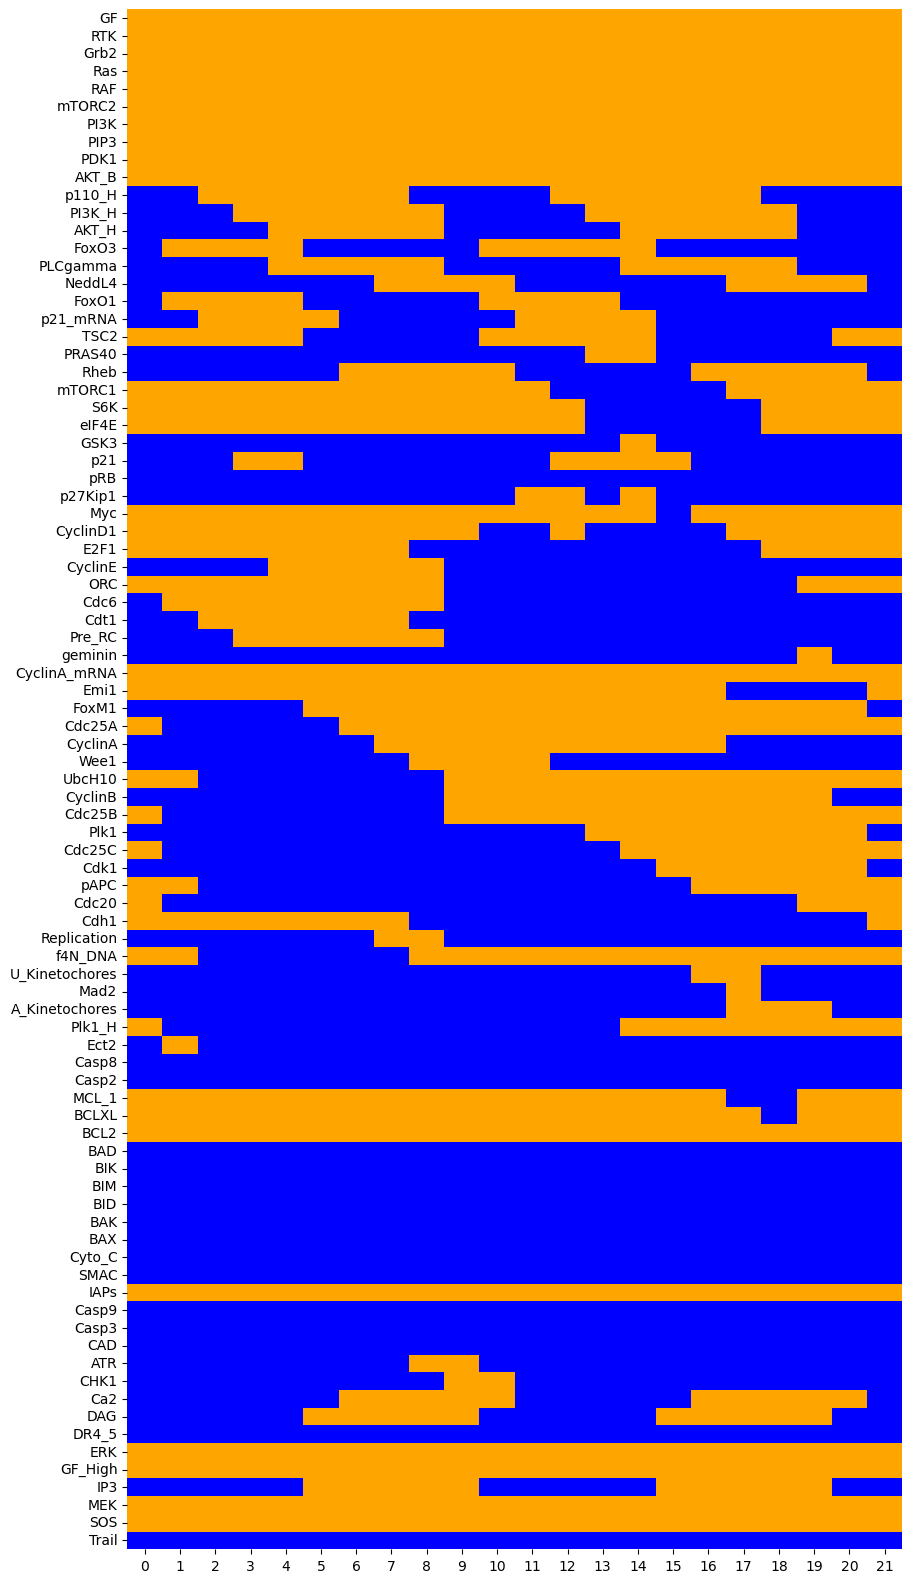

In [14]:
# Function used for plotting the dynamics of molecular species.
def plotting(df):
    custom_cmap = sns.color_palette(['blue', 'orange'])
    fig = plt.figure(figsize=(10, 20))  # Adjust the figure size as needed
    sns.heatmap(df.T, cmap=custom_cmap, annot=False, cbar=False)
    plt.show()
plotting(trace_df)

**Figure 4.** Heat map displaying the sequence of 22 states (columns) forming the synchronous cycle of length 21, with the initial state (first column, index 0) matching the last one (column with index 21). Orange cells denote the active components (rows) at the corresponding cycle state (column), whereas the blue cells denote the suppressed components.

Note that some nodes are never activated along the cycle, while others are always activated. In particular, the apoptotic pathway (BIM, BAX, BAK, CytC, Casp3, Casp9, etc.) is inactive in this sequence, while the cell cycle is activated by the MAPK pathway (RTK, Ras, Raf, PI3K, etc.).

Hence, using different tools, we could also identify the synchronous attractor reported by Sizek *et al.* \[[13](#B13)\], which recapitulates the typical sequence of (in)activation of cell components, including cyclins. However, as this synchronous cyclic attractor is not expected to precisely reproduce the biological cyclic behaviour, a deeper analysis of the timing of cyclin (in)activations will be considered using asynchronous updating in §3.7.

Of note, Sizek *et al.* \[[13](#B13)\] reported that the observed cyclic behaviour is sensitive to the updating strategy used. To further characterize this sensitivity, *bioLQM* can be further used to compute traces starting from the same initial state but using random asynchronous updating, i.e. selecting one node among all nodes called to be updated at each state, with identical probabilities assigned to all single node transitions. This can be achieved using the following code cell:

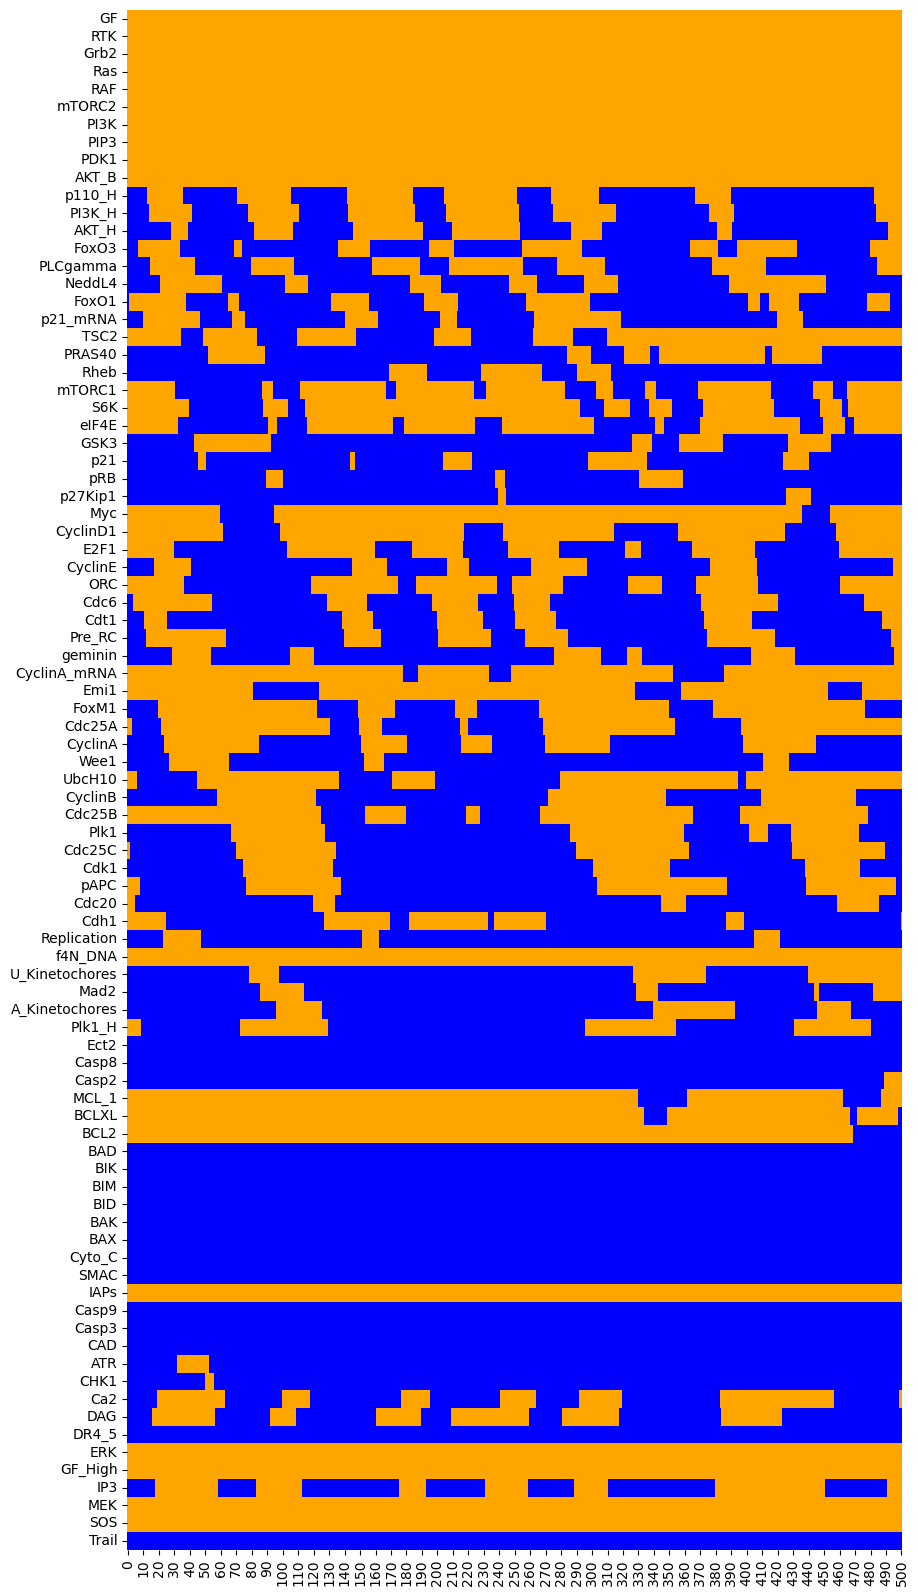

CPU times: user 3.21 s, sys: 1.52 s, total: 4.72 s
Wall time: 6.39 s


In [15]:
%%time
# Random asynchronous trace considering a maximum of 500 steps.
random = biolqm.random(model_biolqm, f"-i {init_str} -m 500")
random_df = pd.DataFrame( [s for s in random] )
plotting(random_df)

**Figure 5.** Heat map displaying a sequence of 500 states (columns) resulting from a random asynchronous updating of the model, starting with the same initial state shown in **figure 4**. Orange cells denote the active components (rows) at the corresponding cycle state (column), whereas the blue cells denote the suppressed components.

This cell takes a few seconds to execute. Note that a longer maximal number of steps (500) is considered here because we do not know if the trace will end up in an asynchronous cycle, or how long such a cycle might be. 

In the heatmap shown in **figure 5**, we can observe a transient oscillating pattern, but this pattern gets progressively degraded along the simulation. This is due to the random choice of transitions whenever several components are called to switch their values at a given state, according to their logical rules. Of note, if we repeat the same random asynchronous simulation, we typically end up with a different transient oscillating pattern.

Interestingly, when large enough maximal step numbers are considered, simulations ultimately lead to a stable state corresponding to an apoptotic fate. To visualise this, we provide the code for a simulation using a maximum number of steps set to 2000, which needs to be uncommented to be run.

In [16]:
# %%time
# Random asynchronous trace considering a maximum of 2000 steps.
# This high number is chosen in order to visualise the deriviation toward a stable state.
# random = biolqm.random(model_biolqm, f"-i {init_str} -m 2000")
# random_df = pd.DataFrame( [s for s in random] )
# plotting(random_df)

In their article, Sisek *et al.* defined a biased transition order to enforce a more robust cyclic behaviour. Hereafter, we propose an alternative approach to deepen our understanding of the asynchronous behaviour of the model, taking advantage of the software *MaBoSS* \[[17](#B17)\] to integrate over a large number of potentially different traces.

### 3.7. Using MaBoSS software to perform stochastic simulations of the wild-type model

It is difficult to build the asynchronous state transition graph and analyse the transient dynamics of such complex models. To cope with this issue, we use *MaBoSS*, a tool performing stochastic simulations over Boolean networks based on the continuous-time *Markov chain* formalism, relying on the *Gillespie algorithm* \[[17](#B17)\]. The software enables the generation of *time plots* showing the evolution of mean component values (or patterns thereof), as well as of *pie charts* showing the probabilities of the different model states reached at the end of the simulation.

The *bioLQM* model can be converted into the format required by *MaBoSS* with the following code cell:

In [17]:
# Conversion of bioLQM model into the MaBoSS format.
model_maboss = biolqm.to_maboss(model_biolqm)

After loading the model, simulation parameters can be modified with the
following code cell:

In [18]:
# Delineation of MaBoSS simulation parameters.
model_maboss.update_parameters(sample_count=5000,max_time=200, time_tick=0.5)

This code cell defines the following simulation parameters:

* Number of simulations: 5000.
* Maximum length of the simulation (in arbitrary unit): 200.
* Interval between two time points: 0.5.

Note that *MaBoSS* uses continuous-time Boolean modelling and requires the specification of a maximum simulation length and an interval between time points. All the stochastic simulations reported in the notebook use these same simulation parameters.

Next, we define a WT version of the model, called *WT*, and we select the *external variables*, i.e. the variables for which the values will be reported during the simulation. This is crucial to avoid combinatorial explosion.

In [19]:
# Define a wildtype model "WT" and select external variables.
WT = model_maboss.copy()
## Select outputs for visualisation of the results.
WT.network.set_output(('CyclinB','Casp3','PI3K_H','E2F1','Replication','p21', 'RTK'))

Note that when exporting a model to *MaBoSS* with *bioLQM* or *GINsim*, all the initial values are set to 0 by default. Hereafter, we assign to the model the initial conditions defined by Sizek *et al.* \[[13](#B13)\] in their fig. 6.

In [20]:
# Define a state corresponding to Sizek’s initial condition
active_init = [ k for (k,v) in init.items() if v==1 ]
maboss.set_nodes_istate(WT, active_init, [0,1])

*MaBoSS* simulation results can be graphically displayed as *time plots* showing the probabilities of active nodes or model states (vectors of active nodes) over time, or as *pie charts* showing the probabilities of the final states (i.e. the states reached at the end of the simulations). In brief, the trajectories plotted on these graphs represent mean trajectories of 5000 single trajectories focusing on a subset of seven selected nodes. It is possible to visualise the activity of each of these nodes over time (**figure 6**, upper left), or the evolution of model states defined as configurations of active nodes (**figure 6**, upper right), which can also be displayed as a pie chart for the last time point considered (**figure 6**, lower left).

It is also possible to compute the *state entropy* (H) and the *transition entropy* (TH) over time (**figure 6**, lower right), which can be interpreted as signatures for the stable states or cyclic attractors. These curves provide a means to check the nature of the attractors of the model. Entropy measures the ‘disorder’ of the system studied. A very low transition entropy at the end of a simulation thus suggests that the system has reached an equilibrium, while a positive state entropy may suggest the existence of a cyclic attractor or the occurrence of multiple stable states (for more details, see \[[18](#B18)\]).

The following code cell launches a simulation of the WT model with *MaBoSS*, using the parameters defined above:

In [21]:
%%time
# Run a MaBoSS simulation
run_WT = WT.run()

CPU times: user 0 ns, sys: 3.08 ms, total: 3.08 ms
Wall time: 49.9 s


The execution of this code cell takes less than a minute. To graphically visualise the results of this simulation in terms of node or model states trajectories, of final model states repartition, and of entropy curves, we can use the following code cell:

Text(0.5, 1.0, 'WT entropy curves')

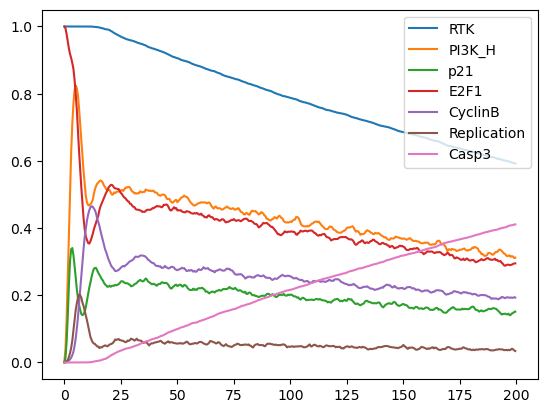

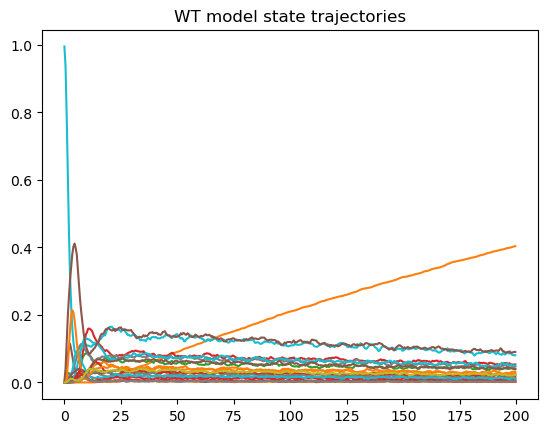

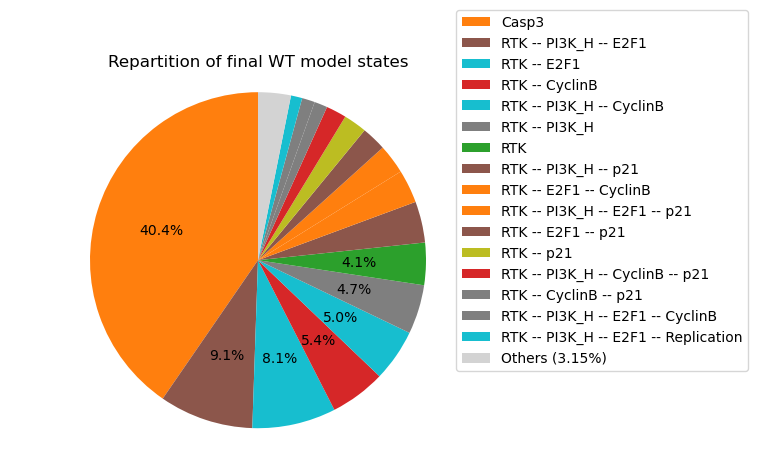

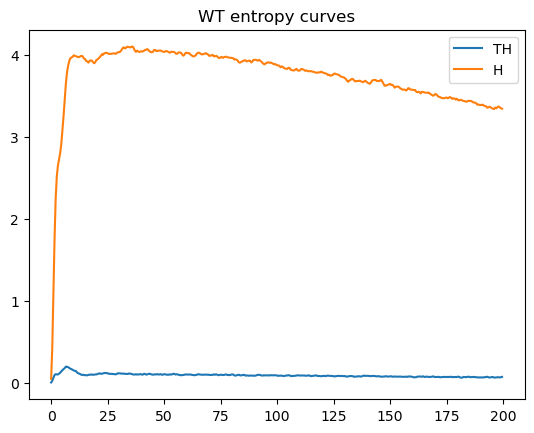

In [22]:
# Plot the trajectories of the WT simulation for selected nodes.
run_WT.get_nodes_probtraj().plot(legend=True)
# Plot the trajectories of the WT simulation with model states.
run_WT.plot_trajectory(legend=False)
plt.title('WT model state trajectories')
# Plot pie chart.
run_WT.plot_piechart()
plt.title('Repartition of final WT model states')
# Plot the state and transition entropy curves.
run_WT.plot_entropy_trajectory()
plt.title('WT entropy curves')

**Figure 6.** *MaBoSS* simulations of the WT model. Upper left panel: trajectories for a subset of nodes. Upper right panel: trajectories for a subset of model states (legend in the lower left panel). Lower left panel: pie chart representing the probabilities for the model states at maximum time (time = 200). Lower right panel: entropy (H) and transition entropy (TH) time plots.

The simulations reveal a transient cyclic-like behaviour, which is eventually lost due to the spontaneous Casp3 activation, thereby revealing the progressive dominance of the apoptotic stable state.

The state entropy initially rises abruptly, and later slowly decreases. In parallel, the transition entropy curve displays a little peak before remaining close to zero, with some noise. Together, these two curves are suggestive of a transient periodic behaviour, which ultimately collapses as more and more cells trigger apoptosis.

Next, we can use *MaBoSS* to study the impact of changes in the initial conditions on the dynamic behaviour of the model. In the preceding simulation, all death signals were initially OFF. Hereafter, we assess the effect of activating TRAIL, a ligand binding to death receptors of tumour cells and initiating the death pathways, while keeping the rest of the other initial conditions unchanged. Note that TRAIL is an input of the death module and thus not regulated. Such inputs are set to either 0 or 1 in the initial conditions, thereby conveying the status of the environment. The following code cell defines a copy of the WT model, triggers TRAIL level to 1 at the initial state, performs the simulation and finally displays the results:

Text(0.5, 1.0, 'Entropy curves for WT model with dead signal ON')

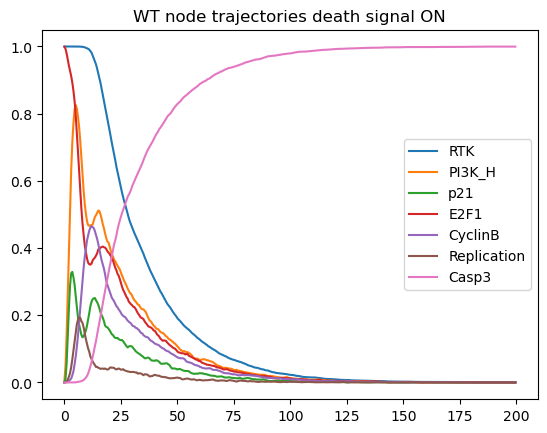

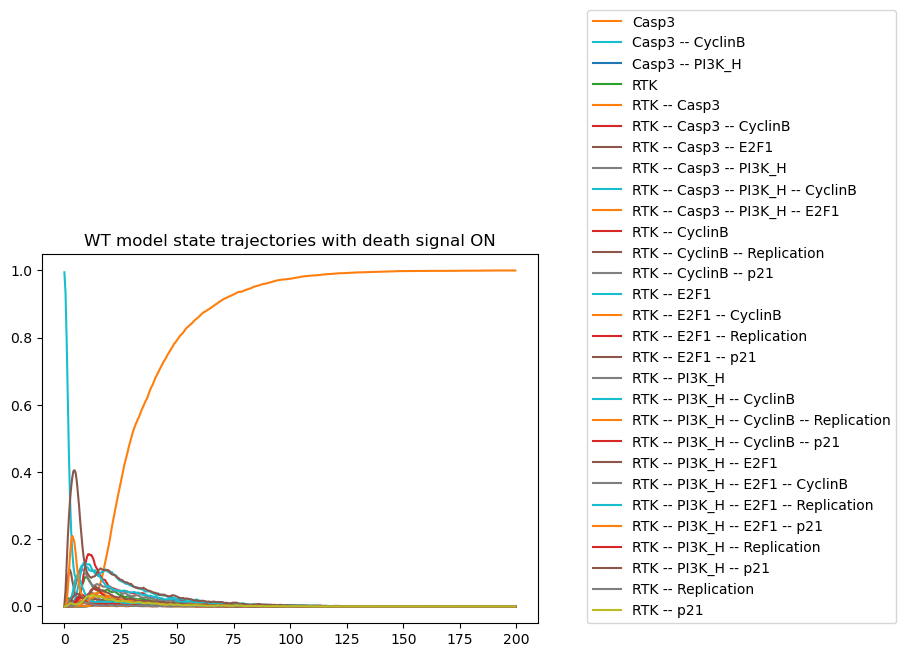

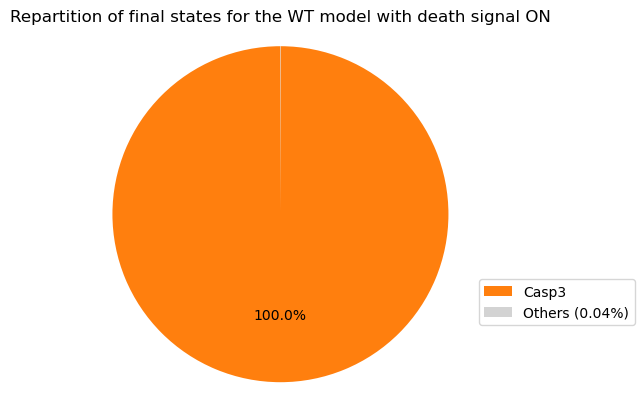

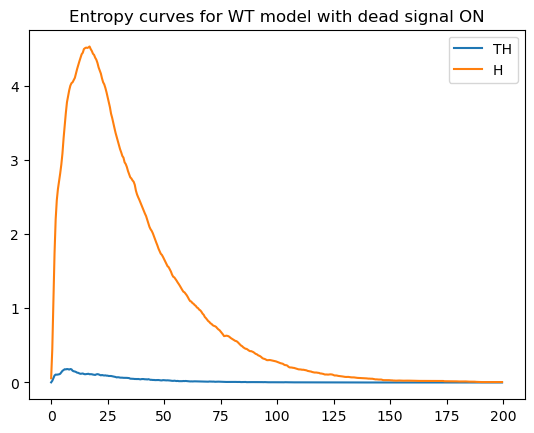

In [23]:
# Copy of the WT model with Trail ON at the initial state.
WT_death = WT.copy()
maboss.set_nodes_istate(WT_death, ["Trail" ] + active_init, [0,1])
# Run a MaBoSS simulations using the modified initial conditions.
WT_death.update_parameters(sample_count=5000,max_time=200, time_tick=0.5)
run_WT_death = WT_death.run()
# Plot the WT node trajectories with dead signal ON.
run_WT_death.get_nodes_probtraj().plot(legend=True)
plt.title('WT node trajectories death signal ON')
# Plot the WT model state trajectories with dead signal ON.
run_WT_death.plot_trajectory(legend=True)
plt.title('WT model state trajectories with death signal ON')
# Plot WT pie chart with dead signal ON.
run_WT_death.plot_piechart(legend=True)
plt.title('Repartition of final states for the WT model with death signal ON')
# Plot the WT state and transition entropy curves with dead signal ON.
run_WT_death.plot_entropy_trajectory()
plt.title('Entropy curves for WT model with dead signal ON')

**Figure 7.** *MaBoSS* simulations for the WT condition with death receptor signals active. Upper left panel: trajectories for a subset of nodes. Upper right panel: trajectories for a subset of model states. Lower left panel: pie chart displaying the probabilities for the model states at maximum time (time = 200). Lower right panel: entropy (H) and transition entropy (TH) time plots.

Looking at the graphs of **figure 7**, we can see that the activation of TRAIL at the initial state enables a faster rise of Casp3 and thus of the apoptotic fate. In parallel, the state entropy drops much faster, while the transition entropy stabilises around zero, suggesting a stable state situation.

### 3.8. Mutant simulations with MaBoSS


In their article, Sizek *et al.* report a sophisticated analysis of the role and dynamical properties of the PI3K/AKT1 pathway, and recapitulate deleterious effects of alterations thereof. They further analyse the impact of the blocking of the Polo-like kinase 1 (Plk1, a mitotic driver and chemotherapy target) on cell cycle progression.

Hereafter, we focus on the analysis of the impact of the perturbations of other model components, using the *MaBoSS* software. Such perturbations can be understood as mutations that patients bear, or as targets of drugs that would suppress proliferation or increase apoptosis.

#### 3.8.1. Stochastic simulation of ectopic Casp8 activity

Casp8 is a caspase initiating the apoptotic cascade. By changing its activity (ectopic activity or knockdown), we can explore its role in triggering cell death. Using the following code cell, we first simulate the impact of a constant activation of Casp8 and display the resulting time plot and pie chart.

In [24]:
%%time
# MaBoSS simulation for Casp8 ectopic activity.
mut_Casp8_ON = WT.copy()
mut_Casp8_ON.mutate("Casp8", "ON")
mutres_Casp8_ON = mut_Casp8_ON.run()

CPU times: user 2.87 ms, sys: 639 μs, total: 3.51 ms
Wall time: 13.4 s


Text(0.5, 1.0, 'Repartition of final model states for Casp8 ectopic activity')

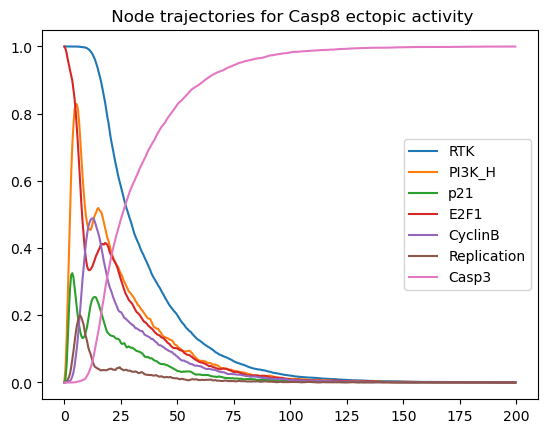

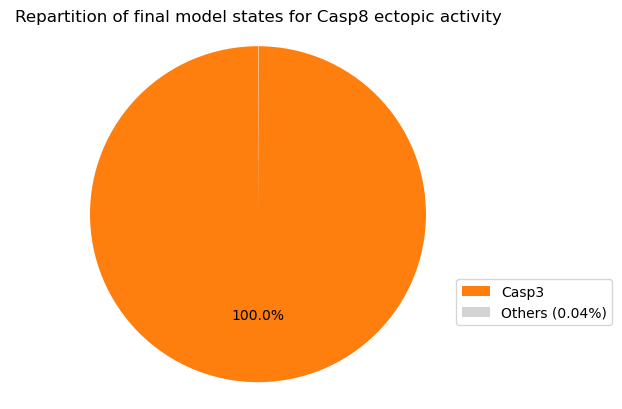

In [25]:
# Plot the time plot and pie chart for Casp8 ectopic activity.
mutres_Casp8_ON.get_nodes_probtraj().plot(legend=True)
plt.title(' Node trajectories for Casp8 ectopic activity')
mutres_Casp8_ON.plot_piechart()
plt.title('Repartition of final model states for Casp8 ectopic activity')

**Figure 8.1**. *MaBoSS* simulations for Casp8 mutants: node trajectories and pie chart showing the asymptotic solutions for Casp8 overexpression.

Based on these results, we can conclude that the ectopic expression of Casp8 drives the cells into apoptosis faster, whether the death signal (TRAIL) is ON or OFF. This suggests that death is not dependent on external signals in this context: the cell becomes independent from the death receptor engagement and apoptosis is constantly activated.

#### 3.8.2. Stochastic simulation of Casp8 knockdown

We can also check the impact of a full knockdown of Casp8 by executing
the following code cell:

In [26]:
%%time
# MaBoSS simulation for Casp8 knockdown.
mut_CASP8_OFF = WT.copy()
mut_CASP8_OFF.mutate("Casp8", "OFF")
mutres_CASP8_OFF = mut_CASP8_OFF.run()

CPU times: user 4.11 ms, sys: 895 μs, total: 5 ms
Wall time: 46.9 s


Text(0.5, 1.0, 'Repartition of final states for the CASP8 knockdown model')

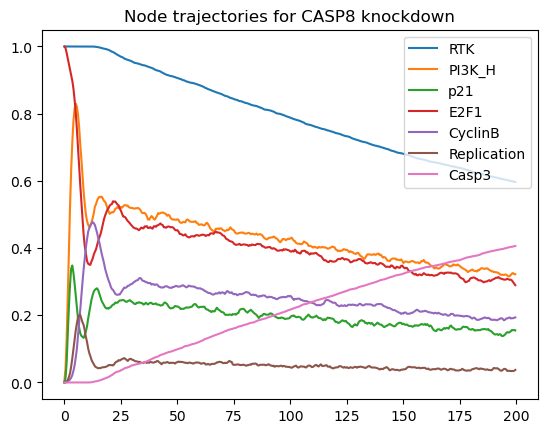

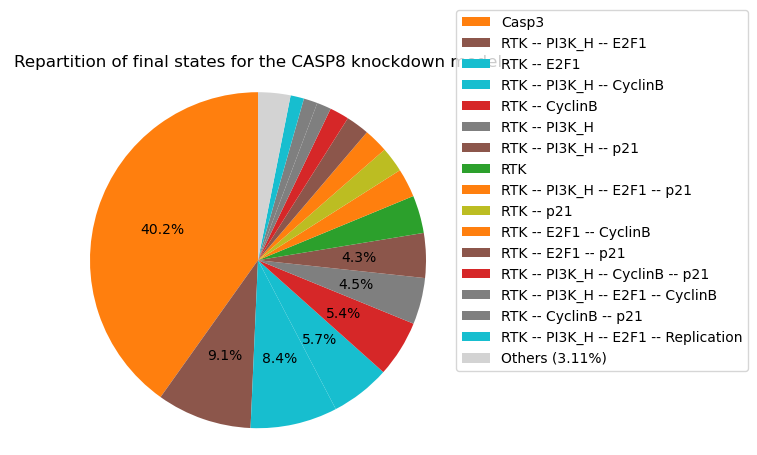

In [27]:
# Plot the trajectories of the model states.
mutres_CASP8_OFF.get_nodes_probtraj().plot(legend=True)
plt.title('Node trajectories for CASP8 knockdown')
# Plot the time plot and pie chart for Casp8 ectopic activity.
mutres_CASP8_OFF.plot_piechart(legend=True)
plt.title('Repartition of final states for the CASP8 knockdown model')

**Figure 8.2**. *MaBoSS* simulations for Casp8 mutants: node trajectories and pie chart representing the probabilities for the model states at the end of simulations for Casp8 knockdown.

Casp3 is initially blocked but becomes ultimately activated, like in the wild-type case, independently of the status of Casp8. Hence, the model predicts that apoptosis (represented by Casp3 activity) can ultimately occur even in the absence of Casp8 activity. The knockout of Casp8 does not affect the model in the absence or presence of TRAIL.

Of note, it is possible to knock out a specific interaction with *bioLQM*, using the syntax: `target:regulator%0`, denoting a blockade of the interaction exerted by the regulator onto the target:

In [28]:
# Model perturbation blocking the regulation of Casp3 by Casp8.
m_perturbed = biolqm.perturbation(model_biolqm, "Casp3:Casp8%0")
# Translation of the edgetic variant model into MaBoSS format.
perturbed_maboss = biolqm.to_maboss(model_biolqm)

Using a bit of *Python* code, it is further possible to systematically explore a series of mutants, and to filter the results. In this respect, we provides an example of such code in the next subsection, considering 10 mutant simulations (inhibition and activation of five different nodes), and filtering those enabling a blockade of apoptosis, denoted by the suppression of Casp3 activation, while keeping the cell cycle active. This would correspond to a highly proliferative phenotype, with some alterations correlating with cancer patient conditions.

Overall, this analysis shows the important but not necessary role of Casp8 in triggering apoptosis in this model. The gradual activation of Casp3, even in the absence of Casp8, may be an artefact of the model, or could be interpreted as an intrinsic propensity of cells to die after multiple rounds of divisions. In the latter case, the model would benefit from the inclusion of more details regarding the mechanisms triggering cell death.


#### 3.8.3. Multiple mutant simulations

It is further possible to systematically explore a series of mutants, and to filter the results. In this respect, the notebook provides an example of such code, considering ten mutant simulations (inhibition and activation of five different nodes), and filtering those enabling a blockade of apoptosis, denoted by the suppression of Casp3 activation, while keeping the cell cycle active. This would correspond to a highly proliferative phenotype, with some alterations correlating with cancer patient conditions.


In [29]:
# Import a MaBoSS pipeline enabling multiple simulations.
from maboss.pipelines import simulate_single_mutants, filter_sensitivity
# Define a list of mutants and output parameters for MaBoSS simulations.
list_mutants = ["PI3K_H", "p110_H", "p21", "Plk1", "FoxO3"]
explore_mutants = WT.copy()
explore_mutants.network.set_output(["Casp3", "CyclinA", "CyclinB", "CyclinE"])

CPU times: user 247 ms, sys: 4.75 ms, total: 252 ms
Wall time: 4min 24s


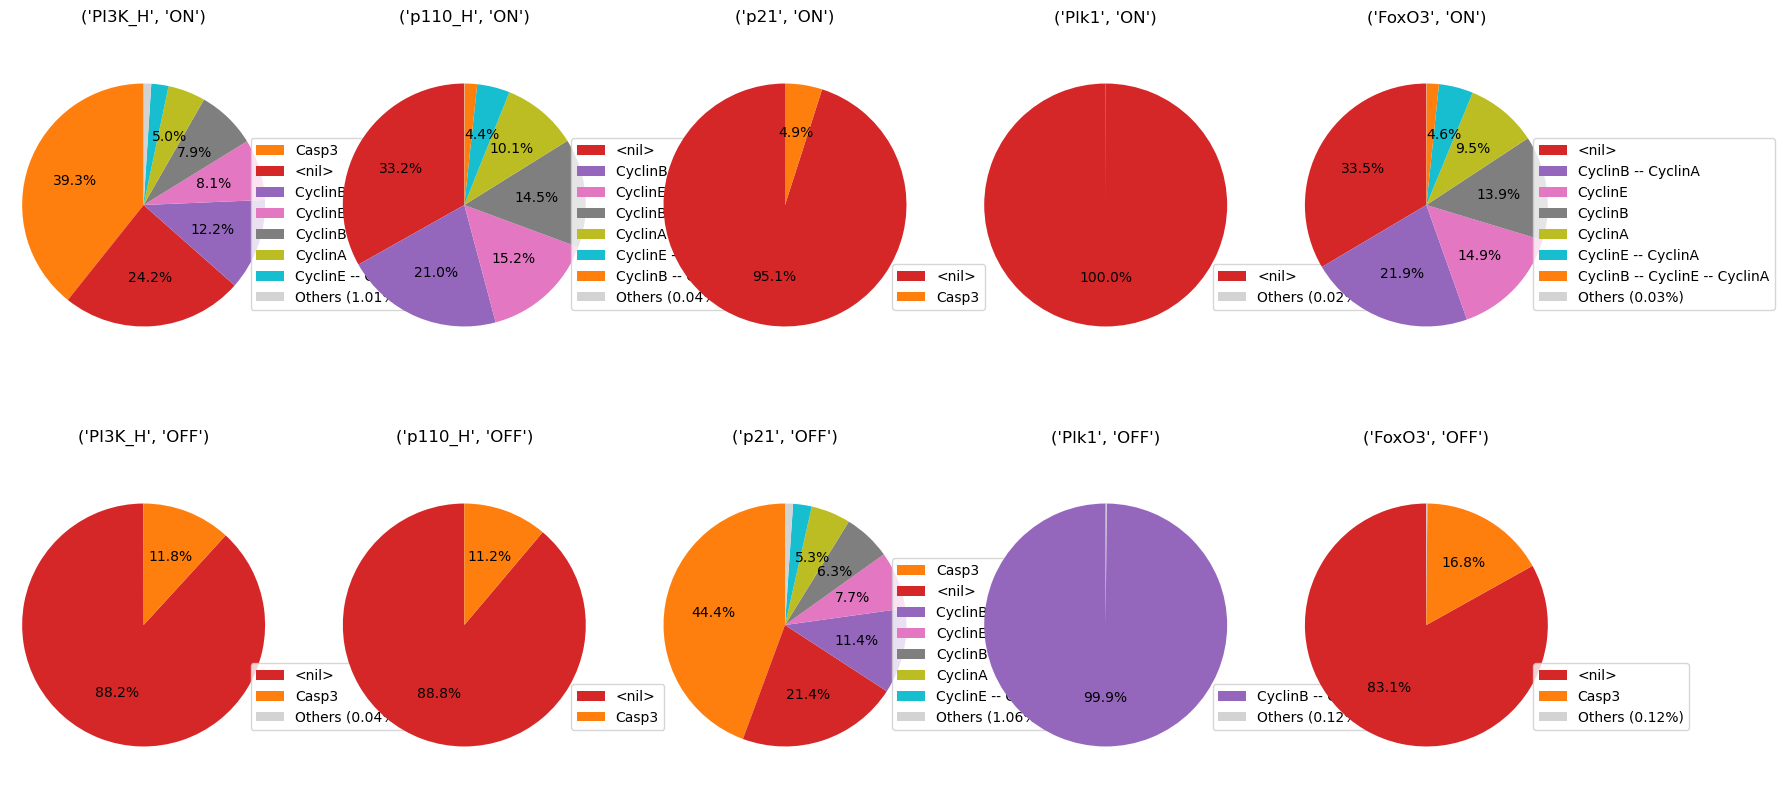

In [30]:
%%time
# Compute MaBoSS simulations for both loss-of-function and ectopic activations for each listed component. 
results = simulate_single_mutants(explore_mutants, list_mutants, sign='BOTH')
fig, ax = plt.subplots(2,5,figsize=(20,10))
# Display the results of MaBoSS simulations as pie charts.
for i, (name, result) in enumerate(results.items()):
    axes = ax[(i//5), (i%5)]
    result.plot_piechart(axes=axes)
    axes.set_title(name)

/opt/conda/lib/python3.11/site-packages/maboss/figures.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


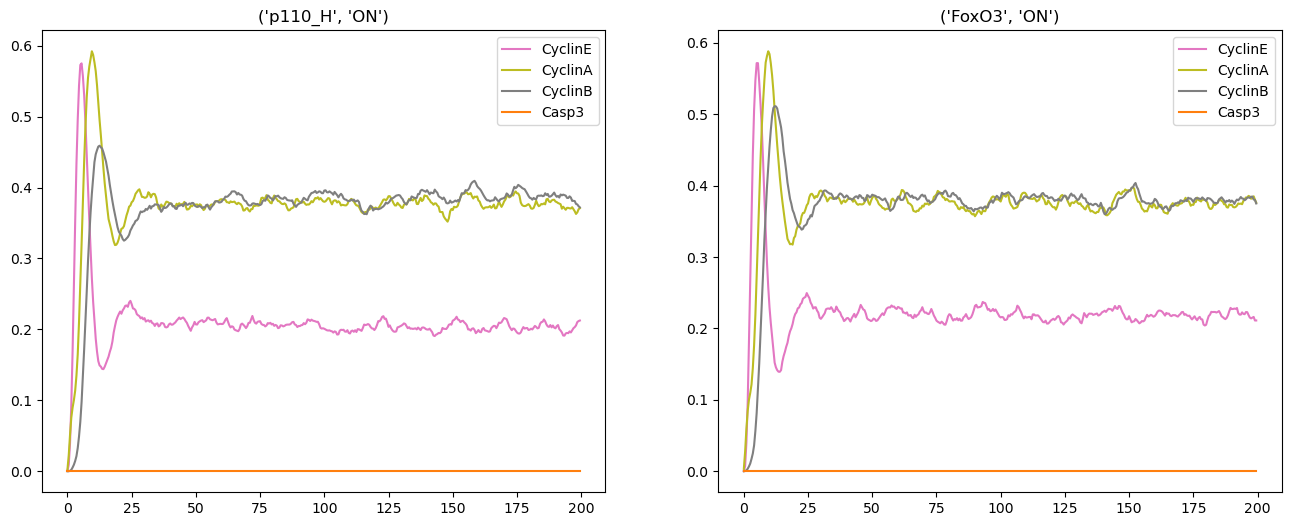

In [31]:
# Filter MaBoSS simultations regarding their capacity to turn down Casp3 activation.
filtered_results = filter_sensitivity(results, node='Casp3', maximum=0.01)
filtered_results = filter_sensitivity(filtered_results, node='CyclinE', minimum=0.15)
fig, ax = plt.subplots(1,len(filtered_results),figsize=(16,6))
for i, (name, result) in enumerate(filtered_results.items()):
    axes = ax[i]
    result.plot_node_trajectory(axes=axes)
    axes.set_title(name)

From this analysis, we can conclude that both p110 and FoxO3 sustained activations are able to turn off Casp3 activity, while maintaining the cycle. Note that we don't use a complete absence of Casp3 activity here (0%) as a filter but instead a quasi absence of activity (1%), as a very small activity might persist.

### 3.9. Deeper analysis of the quasi-cyclic synchronous attractor

In this section, we explore the dynamics of the cell cycle by studying the succession of cyclin activations and inactivations. In continuous frameworks, i.e., models based on ordinary differential equations, it is possible to follow the activations of the cyclins that are crucial to ensure a proper cell cycle. In the WT situation, we expect that the cyclins get activated in the following order: CyclinE, followed by CyclinA, then CyclinB, and get inactivated in the same order. This sequence is not based on a simple cascade, but on complex regulation where new phases are controlled by checkpoints.

In the case of stochastic Boolean simulations, the verification of this sequence of cyclin activations is more challenging. In this respect, we have developed a functionality reporting the probabilities of occurrences of specific node level transitions, thereby enabling the delineation of highly probable orders of activations and inactivations of cyclins over time.

#### 3.9.1. Verification of the order of activations of cyclins in the WT situation by plotting a compressed state transition graph

The following code cells defines a simulation of the WT model focusing on cyclin dynamics.

CPU times: user 2.61 ms, sys: 485 μs, total: 3.09 ms
Wall time: 46.7 s


Text(0.5, 1.0, 'WT cyclins trajectories')

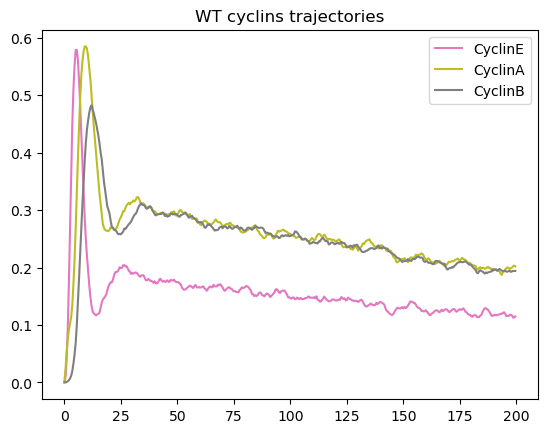

In [32]:
# Cyclin dynamics in the wildtype cyclic attractor.
outputs = ["CyclinA", "CyclinB", "CyclinE"]
WT.network.set_output(outputs)
%time res = WT.run()
res.plot_node_trajectory()
plt.title('WT cyclins trajectories')

We can see that the cyclins follow the expected order with the proper sequence of peaks: first CyclinE around *t* = 5, then CyclinA around *t* = 10, and finally CyclinB around *t* = 15. Note that as *MaBoSS* reports mean probabilities over time, these oscillations are rapidly damped.

We can further compute the frequencies of cyclin activations and inactivations over all individual trajectories of the simulation. To do this, we use a new functionality of *MaBoSS*, estimating the frequencies of transitions between *activity patterns* involving selected nodes, and plot them as a graph. To prevent the explosion of the size of this graph, we only use the three main cyclins responsible for the cyclic attractor. The following code cell computes such transition frequencies and displays the results as a *compressed state transition graph*, i.e. a projection of the transition frequencies computed over the full state space onto the cyclin activity patterns of interest.

CPU times: user 2.06 ms, sys: 379 μs, total: 2.44 ms
Wall time: 45.1 s


Text(0.5, 1.0, 'WT Compressed state transition graph of cyclins')

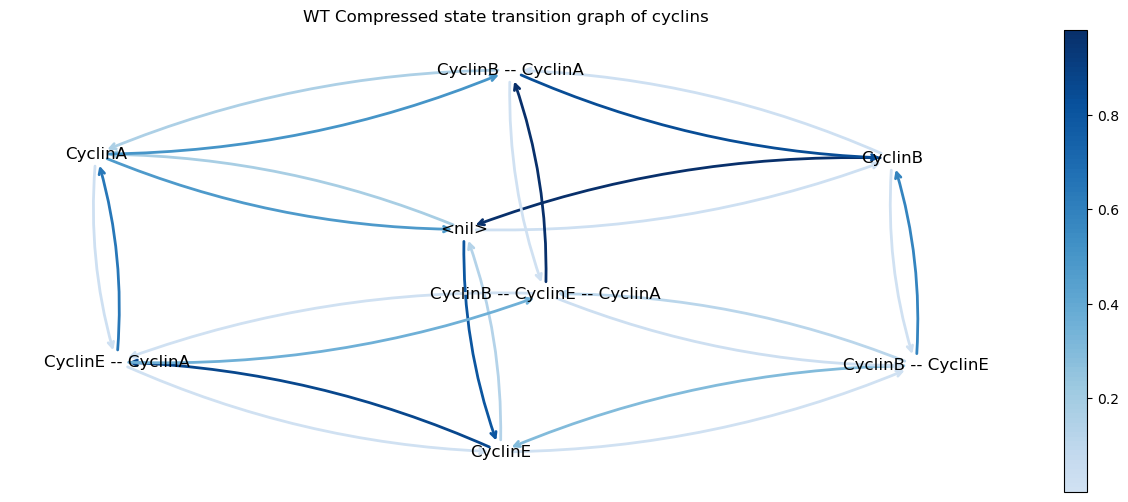

In [33]:
# Compute a compressed state transition graph for the WT.
WT_trajs = WT.copy()
WT_trajs.network.set_observed_graph_nodes(["CyclinA", "CyclinB", "CyclinE"])
%time res_trajs = WT_trajs.run()
res_trajs.get_observed_graph() 
fig, ax = plt.subplots(1,1,figsize=(16,6))
res_trajs.plot_observed_graph(axes=ax)
plt.title('WT Compressed state transition graph of cyclins')

In this graph, the transitions denoted by darker blue arrows have a higher probability of occurring. This representation enables us to visualise the most probable sequence of cyclin activations and inactivations. Starting from the state ‘\<nil\>’ (corresponding to G0), the most probable sequence of state transitions successively involves CyclinE activation, CyclinA activation, CyclinE inactivation, CyclinB activation, CyclinA inactivation and finally CyclinB inactivation, thereby completing the cycle. Note that other cycles can be followed with lower probabilities.

#### 3.9.2. Analysis of the apoptosis triggering timing along the cell cycle

Here, we study the condition leading to apoptotic death, focusing on the point in the cell cycle where Casp3 is activated. We can achieve this using the following code cell:

CPU times: user 0 ns, sys: 4.18 ms, total: 4.18 ms
Wall time: 47.8 s


Text(0.5, 1.0, 'WT Compressed state transition graph of cyclins and Casp3')

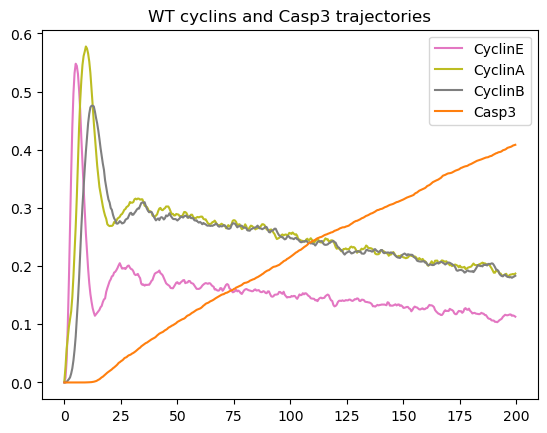

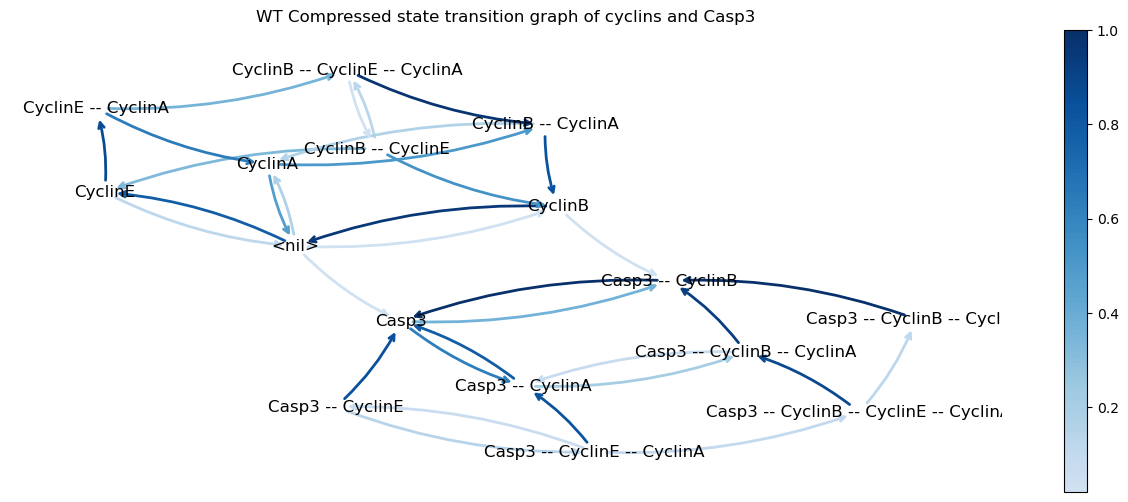

In [34]:
# Compute a compressed state transition graph reavealing Casp3 activation.
outputs =["Casp3", "CyclinA", "CyclinB", "CyclinE"]
WT.network.set_output(outputs)
WT.network.set_observed_graph_nodes(outputs)
%time res = WT.run()
res.plot_node_trajectory()
plt.title('WT cyclins and Casp3 trajectories')
fig, ax = plt.subplots(1,1,figsize=(16,6))
res.plot_observed_graph(axes=ax, prob_cutoff=0.02)
plt.title('WT Compressed state transition graph of cyclins and Casp3')

In the resulting timeplot, we can observe that cells initially follow the expected cycle, but quickly activate Casp3 and are thus led to apoptosis.

In the compressed transition graph, we used a minimum probability threshold (2%) to discard unlikely edges during plotting. We see that there are two main ways to activate apoptosis: from the node `<nil>` (with no active cyclins), which presumably represents the G0 state, and from the node ‘cyclinB’ (with only cyclin B active), which tentatively represents the G2/M phase.

#### 3.9.3. Analysis of cyclin triggering timing in presence of ectopic p110_H activity

In their article, Sizek *et al.* \[[13](#B13)\] reported that p110 activates both PI3K and AKT, which in turn inhibits cell death. In the mutant analyses performed by these authors, p110 played a key role in the interaction between the MAPK module and the apoptotic module. To verify the impact of a forced p110_H activation, we can execute the following code cell:

CPU times: user 0 ns, sys: 2.08 ms, total: 2.08 ms
Wall time: 31 s


Text(0.5, 1.0, 'p110_H++ mutant Compressed state transition graph of cyclins and Casp3')

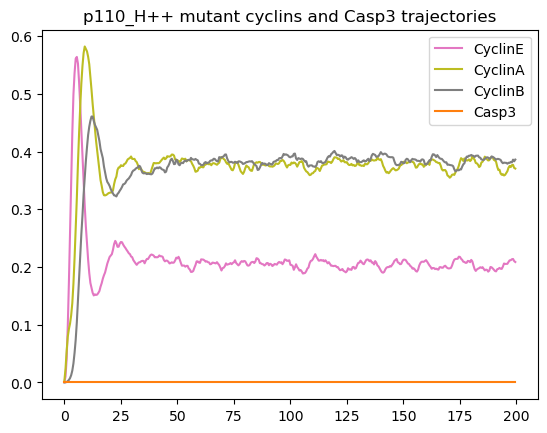

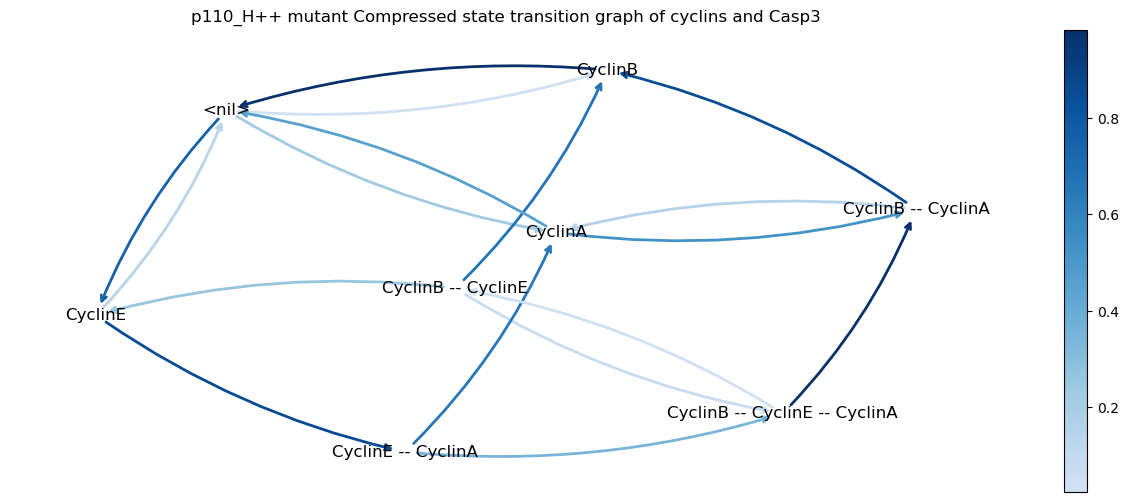

In [35]:
# Analysis of the impact of of forced p110_H activation.
# Copy the WT model and block p110_H ON.
mut_p110 = WT.copy()
mut_p110.mutate('p110_H', 'ON')
# Sumulation of the mutant model.
%time res_mut_p110 = mut_p110.run()
res_mut_p110.plot_node_trajectory()
plt.title('p110_H++ mutant cyclins and Casp3 trajectories')
# Plot the compressed transition graph.
fig, ax = plt.subplots(1,1,figsize=(16,6))
res_mut_p110.plot_observed_graph(axes=ax, prob_cutoff=0.02)
plt.title('p110_H++ mutant Compressed state transition graph of cyclins and Casp3')

As can be seen in the resulting compressed transition graph, the ectopic activity of p110_H completely disables the activation of apoptosis, enabling the maintenance of the oscillatory behaviour.

## 4. Conclusion

The *CoLoMoTo* software suite integrates over 20 tools written in multiple languages, and makes them accessible with a single popular language (*Python*). After providing the instructions to install the suite, this notebook focused on the analysis of a published model of the regulatory network controlling mammalian cell proliferation \[[13](#B13)\], which can be further used as a template for the analysis of any other Boolean model encoded in one of the multiple supported formats (e.g. *sbml-qual*).

The notebook includes *Python* code enabling the reproduction of several of the results reported by the initial publication \[[13](#B13)\], as well as to further extend these results with new stochastic simulation results for WT cells, as well as for various single and double mutants. Using selected tools included in the *CoLoMoTo* suite, we showed how to compute the model attractors with synchronous or asynchronous updating. Although stable states are consistently preserved, our analysis emphasises the sensitivity of synchronous cyclic attractors to the update mode.

We further showed how the use of a probabilistic simulation framework, implemented in the *MaBoSS* software, can provide interesting information on the transient behaviour of such a complex model, for WT conditions, as well as for different types of model perturbations.

Integrating all these analyses into an executable *Jupyter* notebook greatly facilitates their reproducibility, as well as extensions. The notebook can also be used as a template for encoding completely new model analyses.

Due to space constraints, this notebook explicitly covers the use of only a fraction of the tools available in the *CoLoMoTo* suite. However, all integrated tools are accompanied by short specific notebooks available in the *CoLoMoTo Docker* container, as well as on the *CoLoMoTo* website (<https://colomoto.github.io/>). The analyses presented in this notebook can be easily modified or extended by taking advantage of other tools included in the *CoLoMoTo* suite. For example, simulations with different updating modes can also be performed with *mpbn* or *BooleanNet*; *BooN* can be used for stable state analysis; *Pint* can be used to perform automatic search of mutations enforcing or impeding the reachability of a specific attractor; models can be imported from other databases, such as *Cell Collective*, in different formats, such as *BoolSim* or *BoolNet* formats.

#### Aknowledgements
We are grateful to Claudine Chaouiya and Pedro Monteiro for their key
contributions to the development of *GINsim* and to our many colleagues
who contributed tools integrated in the *CoLoMoTo* suite.

#### Funding

This work has been supported by the French Plan Cancer-MIC ITMO, project MoDICeD (grant 20CM114-00). L.C. and L.P. were partly supported by the French ANR, project RD2BOOL (ANR-23-CE45-0014). L.P. was partly supported by France 2030 project ‘AI4scMED’ (grant ANR-22-PESN-0002).

## References

<span id="B1">[1]</span>  Sugita M. Functional analysis of chemical systems in vivo using a
    logical circuit equivalent. II. The idea of a molecular automaton.
    *J Theor Biol* 1963; **4**: 179-184.
    [doi:10.1016/0022-5193(63)90027-4](https://doi.org/10.1016/0022-5193(63)90027-4)

<span id="B2">[2]</span>  Kauffman SA. Metabolic stability and epigenesis in randomly
    constructed genetic nets. *J Theor Biol* 1969; **22**: 437-467.
    [doi:10.1016/0022-5193(69)90015-0](https://doi.org/10.1016/0022-5193(69)90015-0)

<span id="B3">[3]</span>  Thomas R. Boolean formalization of genetic control circuits. *J
    Theor Biol* 1973; **42**: 563-585.
    [doi:10.1016/0022-5193(73)90247-6](https://doi.org/10.1016/0022-5193(73)90247-6)

<span id="B4">[4]</span>  Albert R, Thakar J. Boolean modeling: a logic-based dynamic approach
    for understanding signaling and regulatory networks and for making
    useful predictions. *WIREs Syst Biol Med* 2014; **6**: 353-369.
    [doi:10.1002/wsbm.1273](https://doi.org/10.1002/wsbm.1273)

<span id="B5">[5]</span>  Abou-Jaoudé W, Traynard P, Monteiro P, Saez-Rodriguez J, Helikar T,
    Thieffry D, Chaouiya D. Logical modeling and dynamical analysis of
    cellular networks. *Front Genet* 2016; **7**: 94.
    [doi:10.3389/fgene.2016.00094](https://doi.org/10.3389/fgene.2016.00094)

<span id="B6">[6]</span>  Schwab JD, Kühlwein SD, Ikonomi N, Kühl M, Kestler HA. Concepts in
    Boolean network modeling: What do they all mean? *Comput Struct
    Biotechnol J.* 2020; **18**: 571-582
    [doi:10.1016/j.csbj.2020.03.001](https://doi.org/10.1016/j.csbj.2020.03.001)

<span id="B7">[7]</span>  Thakar J. Pillars of biology: Boolean modeling of gene-regulatory
    networks. *J Theor Biol* 2024; **578**: 111682.
    [doi:10.1016/j.jtbi.2023.111682](https://doi.org/10.1016/j.jtbi.2023.111682)

<span id="B8">[8]</span>  Zerrouk N, Augé F, Niarakis A. Building a modular and multi-cellular
    virtual twin of the synovial joint in Rheumatoid Arthritis. *NPJ
    Digit Med* 2024; **7**: 379. [doi:10.1038/s41746-024-01396-y](https://doi.org/10.1038/s41746-024-01396-y)

<span id="B9">[9]</span>  Hemedan AA, Niarakis A, Schneider R, Ostaszewski M. Boolean
    modelling as a logic-based dynamic approach in systems medicine.
    *Comput Struct Biotechnol J* 2022; **20**: 3161-3172.
    [doi:10.1016/j.csbj.2022.06.035](https://doi.org/10.1016/j.csbj.2022.06.035)

<span id="B10">[10]</span> Tiwari K, Kananathan S, Roberts MG, Meyer JP, Shohan MUS, Xavier A,
    Maire M, Zyoud A, Men J, Ng S, Nguyen TVN, Glont M, Hermjakob H,
    Malik-Sheriff RS. Reproducibility in systems biology modelling. *Mol
    Syst Biol* 2021; **17**: e9982. [doi: 10.15252/msb.20209982](https://doi.org/10.15252/msb.20209982)

<span id="B11">[11]</span> Chaouiya C, Berenguier D, Keating SK, Naldi A, van Iersel MP,
    Rodriguez N, Dräger A, Büchel F, Cokelaer T, Kowal B, Wicks B,
    Gonçalves E, Dorier J, Page M, Monteiro PT, von Kamp A, Xenarios I,
    de Jong H, Hucka M, Klamt S, Thieffry D, Le Novère N, Saez-Rodriguez
    J, Helikar T. SBML qualitative models: a model representation format
    and infrastructure to foster interactions between qualitative
    modelling formalisms and tools. *BMC Syst Biol* 2013; **7**: 135.
    [doi:10.1186/1752-0509-7-135](https://doi.org/10.1186/1752-0509-7-135)

<span id="B12">[12]</span> Naldi A, Hernandez C, Levy N, Stoll G, Monteiro PT, Chaouiya C,
    Helikar T, Zinovyev A, Calzone L, Cohen-Boulakia S, Thieffry D,
    Paulevé L. The CoLoMoTo Interactive Notebook: Accessible and
    Reproducible Computational Analyses for Qualitative Biological
    Networks. *Front Physiol* 2018; **9**: 680.
    [doi:10.3389/fphys.2018.00680](https://doi.org/10.3389/fphys.2018.00680)

<span id="B13">[13]</span> Sizek H, Hamel A, Deritei D, Campbell S, Regan ER. Boolean model of
    growth signaling, cell cycle and apoptosis predicts the molecular
    mechanism of aberrant cell cycle progression driven by hyperactive
    PI3K. *PLoS Comput Biol* 2019; **15**: e1006402.
    [doi:10.1371/journal.pcbi.1006402](https://doi.org/10.1371/journal.pcbi.1006402)

<span id="B14">[14]</span> Naldi A, Hernandez C, Abou-Jaoudé W, Monteiro PT, Chaouiya C,
    Thieffry D. Logical modelling and analysis of cellular regulatory
    networks with GINsim 3.0. *Front Physiol* 2018; **9**: 646.
    [doi:10.3389/fphys.2018.00646](https://doi.org/10.3389/fphys.2018.00646)

<span id="B15">[15]</span> Naldi A. BioLQM: A Java Toolkit for the Manipulation and Conversion
    of Logical Qualitative Models of Biological Networks. *Front
    Physiol* 2018; **9**: 1605. [doi:10.3389/fphys.2018.01605](https://doi.org/10.3389/fphys.2018.01605)

<span id="B16">[16]</span> Naldi A, Remy E, Thieffry D, Chaouiya C. Dynamically consistent
    reduction of logical regulatory graphs. *Theor Comput Sci* 2011;
    **412**: 2207-2218. [doi:10.1016/j.tcs.2010.10.021](https://doi.org/10.1016/j.tcs.2010.10.021)

<span id="B17">[17]</span> Stoll G, Caron B, Viara E, Dugourd A, Zinovyev A, Naldi A, Kroemer
    G, Barillot E, Calzone L. MaBoSS 2.0: an environment for stochastic
    Boolean modeling. *Bioinformatics* 2017; **33**: 2226-2228.
    [doi:10.1093/bioinformatics/btx123](https://doi.org/10.1093/bioinformatics/btx123)

<span id="B18">[18]</span> Stoll G., Viara E., Barillot E., Calzone L. Continuous time boolean
    modeling for biological signaling: application of Gillespie
    algorithm. *BMC Syst Biol* 2012, **6**: 116.
    [doi:10.1186/1752-0509-6-116](https://doi.org/10.1186/1752-0509-6-116)

